# Predicting House Sale Prices - Ames, Iowa Housing Data

**Author:** Majid M. D Ben Ghet
**Date: ** September 15th 2026

This notebook works through a full data science project: taking a real, messy
real estate dataset, applying varous method of data cleaning, exploring it and drawing conclusions, and building a number of prediction models to
estimate a house's sale price from its characteristics.

## 1. Business Understanding

A real estate analytics team wants a way to estimate a **fair listing price** for a
house before it goes on the market, based on things like its size, condition,
location and age. A model like this would help agents:

- price new listings competitively instead of guessing,
- flag listings that look significantly over- or under-priced compared to similar
  houses,
- give buyers a quick "is this a fair price" sanity check.

**Data source:** the dataset covers 1,460 residential home sales in Ames, Iowa, with
about 80 characteristics recorded for each house (size, quality ratings, garage,
basement, neighborhood, year built, and so on) along with the final sale price.

## 2. Setup
We will first start by importing the relevant libraries to our project.

In [49]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "joblib",
])

0

In [50]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

# make sure the output folders exist before we try to save anything into them
if not os.path.exists("../figures"):
    os.makedirs("../figures")

if not os.path.exists("../models"):
    os.makedirs("../models")

# fixing the random seed so the notebook gives the same results every time it is run
RANDOM_STATE = 42

In [51]:
data_path = "data/AmesHousing.csv"
df = pd.read_csv(data_path)
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Data Understanding

Before doing anything else, we take a first look at the data: how big it is, what
types of columns we have, and where the gaps are.

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [53]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
missing_counts = missing_counts.sort_values(ascending=False)

missing_percent = (missing_counts / len(df)) * 100

print("Columns with missing values:", len(missing_counts))
for column_name in missing_counts.index:
    count = missing_counts[column_name]
    percent = missing_percent[column_name]
    print(column_name, "-", count, "missing (", round(percent, 1), "% )")

Columns with missing values: 19
PoolQC - 1453 missing ( 99.5 % )
MiscFeature - 1406 missing ( 96.3 % )
Alley - 1369 missing ( 93.8 % )
Fence - 1179 missing ( 80.8 % )
MasVnrType - 872 missing ( 59.7 % )
FireplaceQu - 690 missing ( 47.3 % )
LotFrontage - 259 missing ( 17.7 % )
GarageType - 81 missing ( 5.5 % )
GarageYrBlt - 81 missing ( 5.5 % )
GarageFinish - 81 missing ( 5.5 % )
GarageQual - 81 missing ( 5.5 % )
GarageCond - 81 missing ( 5.5 % )
BsmtExposure - 38 missing ( 2.6 % )
BsmtFinType2 - 38 missing ( 2.6 % )
BsmtQual - 37 missing ( 2.5 % )
BsmtCond - 37 missing ( 2.5 % )
BsmtFinType1 - 37 missing ( 2.5 % )
MasVnrArea - 8 missing ( 0.5 % )
Electrical - 1 missing ( 0.1 % )


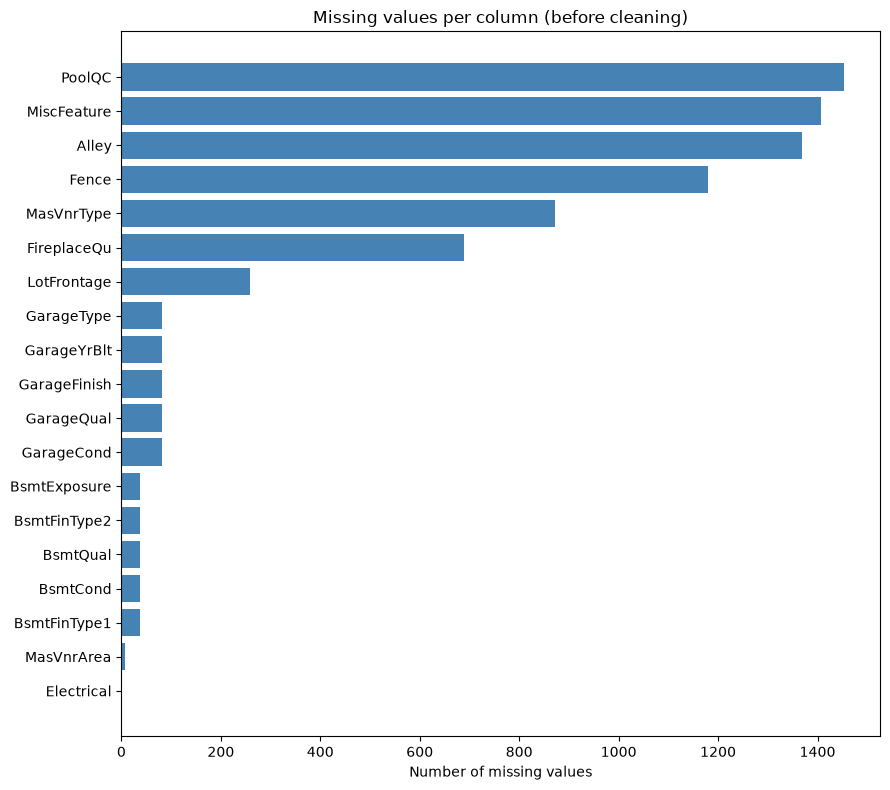

In [54]:
plt.figure(figsize=(9, 8))
plt.barh(missing_counts.index, missing_counts.values, color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Number of missing values")
plt.title("Missing values per column (before cleaning)")
plt.tight_layout()
plt.savefig("../figures/fig_missingness.png", dpi=150)
plt.show()

In [55]:
number_of_duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", number_of_duplicate_rows)

print()
print("Summary of the target variable, SalePrice:")
print(df["SalePrice"].describe())

Number of duplicate rows: 0

Summary of the target variable, SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## 4. Data Preparation

Now we clean the dataset column by column, based on what we found above. We try to
make a sensible, documented decision for every group of missing values rather than
just dropping rows or columns.

### 4.1 Columns where "missing" means we have no data for this observation

For these columns, a missing value should become the category `"None"`, not be
imputed with some average value.

In [56]:
columns_missing_means_none = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]

for column_name in columns_missing_means_none:
    df[column_name] = df[column_name].fillna("None")

still_missing = df[columns_missing_means_none].isnull().sum().sum()
print("Missing values left in these columns after filling with 'None':", still_missing)

Missing values left in these columns after filling with 'None': 0


### 4.2 LotFrontage - truely missing value

`LotFrontage` is the length of street connected to the property. It is missing for
about 18% of houses. Rather than filling every missing value with one single average,
we estimate it using the **median frontage of houses in the same neighborhood**,
since lot sizes tend to be similar within the same neighborhood.

In [57]:
neighborhood_list = df["Neighborhood"].unique()

for neighborhood_name in neighborhood_list:
    is_this_neighborhood = df["Neighborhood"] == neighborhood_name
    median_frontage = df.loc[is_this_neighborhood, "LotFrontage"].median()

    missing_in_neighborhood = is_this_neighborhood & df["LotFrontage"].isnull()
    df.loc[missing_in_neighborhood, "LotFrontage"] = median_frontage

print("Missing LotFrontage values left:", df["LotFrontage"].isnull().sum())

Missing LotFrontage values left: 0


### 4.3 A few remaining columns

- `GarageYrBlt` (year the garage was built) is missing when there is no garage, so we
  fill it with 0 - this is safe since `GarageType` for these same rows is already
  `"None"`, so the model can tell these houses apart.
- `MasVnrArea` (masonry veneer area) missing almost always means there is no veneer,
  so we fill it with 0 square feet.
- `Electrical` has exactly one missing value. With only one row affected, we simply
  fill it with the most common electrical system in the dataset.

In [58]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

most_common_electrical = df["Electrical"].mode()[0]
df["Electrical"] = df["Electrical"].fillna(most_common_electrical)

print("Total missing values remaining in the whole dataset:", df.isnull().sum().sum())

Total missing values remaining in the whole dataset: 0


### 4.4 Fixing a data type

`MSSubClass` is stored as a number, but it is really a coded category (for example,
20 means a 1-story house built after 1946, 60 means a 2-story house built after
1946). If we leave it as a number, the models will wrongly assume that a higher code
means "more" of something, so we convert it to text and let it be treated as a
category instead.

This information can be found in the Iowa state housing regulations page.

In [59]:
df["MSSubClass"] = df["MSSubClass"].astype(str)

### 4.5 Outliers

A scatter plot of living area against sale price is a good way to spot houses that do
not fit the general pattern.

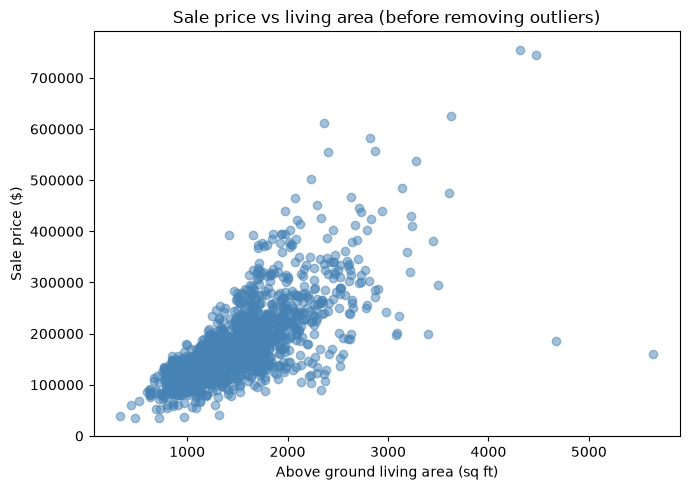

In [60]:
plt.figure(figsize=(7, 5))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.5, color="steelblue")
plt.xlabel("Above ground living area (sq ft)")
plt.ylabel("Sale price ($)")
plt.title("Sale price vs living area (before removing outliers)")
plt.tight_layout()
plt.savefig("../figures/fig_outliers_before.png", dpi=150)
plt.show()

In [61]:
outlier_rows = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
print("Outlier rows found:")
print(outlier_rows[["GrLivArea", "SalePrice"]])

df = df.drop(outlier_rows.index)
df = df.reset_index(drop=True)
print("Shape after removing outliers:", df.shape)

Outlier rows found:
      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000
Shape after removing outliers: (1458, 81)


There are two houses with a very large living area but a surprisingly low sale
price - almost certainly unusual sales (for example, a bank purchase due to loans or a sale for extraordinary circumstances) rather than
typical market transactions. Left in the data, these two rows would pull a linear
model's fit in the wrong direction, so we remove them.

### 4.6 A few engineered features

A couple of extra columns, built from existing ones, tend to be useful for a housing
price model:

- `TotalSF` - total finished square footage (basement + first floor + second floor)
- `HouseAge` - how old the house was in the year it was sold
- `RemodeledFlag` - whether the house was ever remodeled
- `TotalBath` - total number of bathrooms, counting half bathrooms as 0.5

In [62]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

df["RemodeledFlag"] = 0
was_remodeled = df["YearRemodAdd"] != df["YearBuilt"]
df.loc[was_remodeled, "RemodeledFlag"] = 1

df["TotalBath"] = df["FullBath"] + (0.5 * df["HalfBath"]) + df["BsmtFullBath"] + (0.5 * df["BsmtHalfBath"])

df[["TotalSF", "HouseAge", "RemodeledFlag", "TotalBath"]].head()

,TotalSF,HouseAge,RemodeledFlag,TotalBath
0,2566,5,0,3.5
1,2524,31,0,2.5
2,2706,7,1,3.5
3,2473,91,1,2.0
4,3343,8,0,3.5


Row_ID is just row order numbers and hold no value to the inference.

In [63]:
df = df.drop(columns=[column for column in ["row_id", "Id"] if column in df.columns])
print(df.shape)

(1458, 84)


## 5. Exploratory Data Analysis

With the data cleaned up, we can look more closely at what drives the sale price.

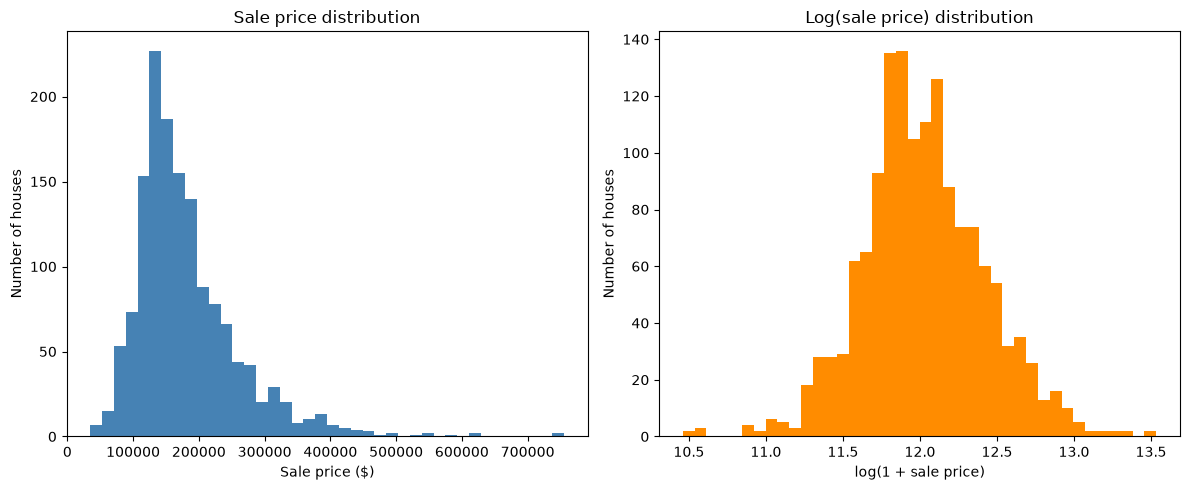

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["SalePrice"], bins=40, color="steelblue")
axes[0].set_title("Sale price distribution")
axes[0].set_xlabel("Sale price ($)")
axes[0].set_ylabel("Number of houses")

log_price = np.log1p(df["SalePrice"])
axes[1].hist(log_price, bins=40, color="darkorange")
axes[1].set_title("Log(sale price) distribution")
axes[1].set_xlabel("log(1 + sale price)")
axes[1].set_ylabel("Number of houses")

plt.tight_layout()
plt.savefig("../figures/fig_target_dist.png", dpi=150)
plt.show()

The raw sale price is right-skewed - most houses sell in a fairly typical range,
but a smaller number of expensive houses stretch the tail out to the right. Taking
the log of the price makes the distribution much closer to symmetric. Because of
this, **we will train our models to predict log(sale price) rather than the raw
price**, and convert predictions back to dollars afterwards. This tends to help
models (especially the linear ones) fit better, since they are no longer thrown off
by a handful of very expensive houses.

In [65]:
numeric_df = df.select_dtypes(include=[np.number])
correlation_with_price = numeric_df.corr()["SalePrice"].sort_values(ascending=False)
print("Numeric features most correlated with sale price:")
print(correlation_with_price.head(11))

Numeric features most correlated with sale price:
SalePrice       1.000000
TotalSF         0.832877
OverallQual     0.795774
GrLivArea       0.734968
TotalBsmtSF     0.651153
GarageCars      0.641047
TotalBath       0.635896
1stFlrSF        0.631530
GarageArea      0.629217
FullBath        0.562165
TotRmsAbvGrd    0.537769
Name: SalePrice, dtype: float64


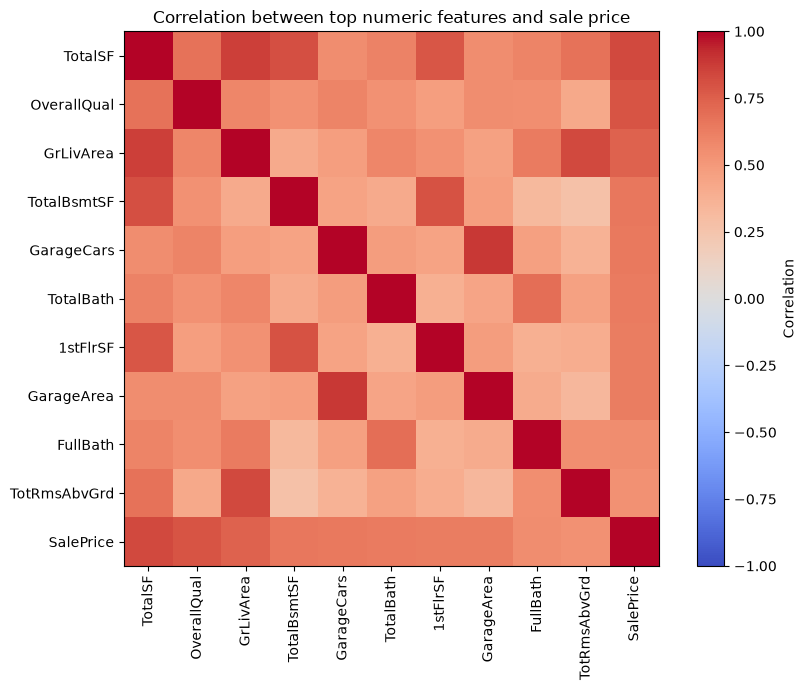

In [66]:
top_features = correlation_with_price.index[1:11]  # skip SalePrice itself, keep the rest of features
columns_for_heatmap = list(top_features) + ["SalePrice"]

correlation_matrix = numeric_df[columns_for_heatmap].corr()

plt.figure(figsize=(9, 7))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(columns_for_heatmap)), columns_for_heatmap, rotation=90)
plt.yticks(range(len(columns_for_heatmap)), columns_for_heatmap)
plt.title("Correlation between top numeric features and sale price")
plt.tight_layout()
plt.savefig("../figures/fig_corr_heatmap.png", dpi=150)
plt.show()

Overall quality, living area and garage/basement size are the numeric features most
strongly related to price, which matches common sense - bigger, higher-quality houses
sell for more. None of the top features are strongly correlated *with each other*
apart from a few expected pairs (like garage cars and garage area), so
multicollinearity should not be a major problem.

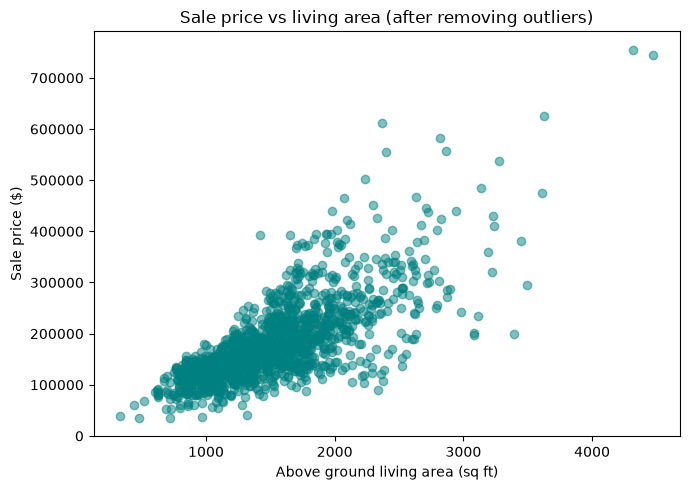

In [67]:
plt.figure(figsize=(7, 5))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.5, color="teal")
plt.xlabel("Above ground living area (sq ft)")
plt.ylabel("Sale price ($)")
plt.title("Sale price vs living area (after removing outliers)")
plt.tight_layout()
plt.savefig("../figures/fig_scatter_grlivarea.png", dpi=150)
plt.show()

In [68]:
median_by_neighborhood = df.groupby("Neighborhood")["SalePrice"].median().sort_values()

neighborhood_groups = []
neighborhood_names_sorted = []

for neighborhood_name in median_by_neighborhood.index:
    prices_in_neighborhood = df.loc[df["Neighborhood"] == neighborhood_name, "SalePrice"]
    neighborhood_groups.append(prices_in_neighborhood.values)
    neighborhood_names_sorted.append(neighborhood_name)

plt.figure(figsize=(12, 6))
plt.boxplot(neighborhood_groups, labels=neighborhood_names_sorted)
plt.xticks(rotation=90)
plt.ylabel("Sale price ($)")
plt.title("Sale price by neighborhood (sorted by median price)")
plt.tight_layout()
plt.savefig("../figures/fig_boxplot_neighborhood.png", dpi=150)
plt.show()

TypeError: boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

<Figure size 1200x600 with 0 Axes>

In [ ]:
quality_values_sorted = sorted(df["OverallQual"].unique())
quality_groups = []

for quality_level in quality_values_sorted:
    prices_at_quality = df.loc[df["OverallQual"] == quality_level, "SalePrice"]
    quality_groups.append(prices_at_quality.values)

plt.figure(figsize=(9, 6))
plt.boxplot(quality_groups, labels=quality_values_sorted)
plt.xlabel("Overall quality rating (1 = worst, 10 = best)")
plt.ylabel("Sale price ($)")
plt.title("Sale price by overall quality rating")
plt.tight_layout()
plt.savefig("../figures/fig_boxplot_quality.png", dpi=150)
plt.show()

Both plots show a clear, fairly steady relationship: better neighborhoods and higher
quality ratings both push the sale price up, with quality in particular showing an
almost step-like increase in median price at each higher rating. This is a good sign
- it means the target has a strong, learnable relationship with features the model
will have access to, rather than being mostly noise.

## 6. Modeling

### 6.1 Preprocessing pipeline

Before fitting any model we need to:

- fill in any remaining gaps (a safety net, in case the test set has a pattern of
  missingness we did not see in training),
- scale the numeric columns so that features measured on very different scales
  (square footage vs a 1-10 rating) do not unfairly dominate the linear/neural
  network models,
- turn the categorical columns (like `Neighborhood`) into numeric columns using
  one-hot encoding, since scikit-learn models cannot use text directly.

We do this with a `ColumnTransformer` so that the exact same steps are applied
consistently to training data, test data, and any new data later on.

In [ ]:
X = df.drop(columns=["SalePrice"])
y = np.log1p(df["SalePrice"])

numeric_columns = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric columns:", len(numeric_columns))
print("Number of categorical columns:", len(categorical_columns))

Number of numeric columns: 39
Number of categorical columns: 44


C:\Users\Majid\AppData\Local\Temp\ipykernel_15596\2314525379.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # sparse_output=False keeps the encoded columns as a plain array, which
    # is easy to work with for a dataset this small
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_columns),
    ("categorical", categorical_transformer, categorical_columns)
])

### 6.2 Train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 1166
Test rows: 292


### 6.3 Hyperparameter tuning

Before picking the final settings for each model, we run a small grid search on the
Random Forest to see whether a bigger forest or deeper trees actually help. The grid
is kept deliberately small  the point here is to show the tuning process, not to
search every possible combination.

In [73]:
tuning_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE))
])

param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [10, None]
}

grid_search = GridSearchCV(
    tuning_pipeline, param_grid, cv=3, scoring="neg_root_mean_squared_error"
)
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validated RMSE (log price):", -1 * grid_search.best_score_)

Best parameters found: {'model__max_depth': None, 'model__n_estimators': 300}
Best cross-validated RMSE (log price): 0.13790043064815408


### 6.4 Choosing the models to compare

We compare six models that go from very simple to more complex, so we can see how
much the extra complexity actually buys us:

- **Linear Regression** - the simplest possible baseline, assumes a linear
  relationship between features and price.
- **Ridge Regression** - a linear model with regularization (adds a penalty on the regression weights), which should be more
  stable given how many correlated features (like garage size and garage cars) are
  in this dataset.
- **Decision Tree** - can capture non-linear relationships and interactions between
  features, and is very interpertable.
- **Random Forest** - an ensemble of many decision trees, usually more accurate and
  more stable than a single tree. using the tuning step above.
- **Gradient Boosting** - another tree ensemble, but builds trees one at a time to
  correct the previous trees' mistakes. Often the strongest performer on tabular
  data like this.
- **Neural Network (MLP)** - a small multi-layer perceptron, included as the more
  complex model. Neural networks usually need a lot more data (and careful tuning)
  to beat tree ensembles on a tabular dataset this size, so it is included as much
  for comparison as for raw accuracy.

In [74]:
best_n_estimators = grid_search.best_params_["model__n_estimators"]
best_max_depth = grid_search.best_params_["model__max_depth"]

models_to_try = {}
models_to_try["Linear Regression"] = LinearRegression()
models_to_try["Ridge Regression"] = Ridge(alpha=10.0, random_state=RANDOM_STATE)
models_to_try["Decision Tree"] = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)
models_to_try["Random Forest"] = RandomForestRegressor(
    n_estimators=best_n_estimators, max_depth=best_max_depth, random_state=RANDOM_STATE
)
models_to_try["Gradient Boosting"] = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
)
models_to_try["Neural Network (MLP)"] = MLPRegressor(
    hidden_layer_sizes=(64, 32), max_iter=2000, early_stopping=True, random_state=RANDOM_STATE
)

print("Models to compare:", list(models_to_try.keys()))

Models to compare: ['Linear Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Neural Network (MLP)']


### 6.5 Training and comparing the models

For each model we build a full pipeline (preprocessing + model), fit it on the
training data, and then check how well it does on the test data it has never seen.
We also run 5-fold cross-validation on the training data, as an extra check that the
test-set result was not just a lucky split.

In [75]:
fitted_pipelines = {}
results_list = []

cross_validation_splitter = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name in models_to_try:
    current_model = models_to_try[model_name]

    full_pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", current_model)
    ])

    full_pipeline.fit(X_train, y_train)

    predictions_log = full_pipeline.predict(X_test)

    # the plain (unregularized) Linear Regression model has a lot of one-hot
    # encoded columns to deal with relative to the number of training rows,
    # which makes it numerically unstable - a handful of predictions can come
    # out as wildly unrealistic values. We clip predictions back to a sensible
    # range around the prices seen in training so a few unstable predictions
    # do not blow up the error metrics. This instability is exactly why we
    # also try Ridge regression, which adds regularization to fix this.
    lowest_reasonable_log_price = y_train.min() - 2
    highest_reasonable_log_price = y_train.max() + 2
    predictions_log = np.clip(predictions_log, lowest_reasonable_log_price, highest_reasonable_log_price)

    # convert both predictions and true values back from log price to dollars,
    # so the error metrics are easy to interpret
    predictions_dollars = np.expm1(predictions_log)
    actual_dollars = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(actual_dollars, predictions_dollars))
    mae = mean_absolute_error(actual_dollars, predictions_dollars)
    r2 = r2_score(actual_dollars, predictions_dollars)

    cv_scores = cross_val_score(
        full_pipeline, X_train, y_train,
        cv=cross_validation_splitter, scoring="neg_root_mean_squared_error"
    )
    cv_rmse_log = -1 * cv_scores.mean()

    print(model_name)
    print("  Test RMSE ($):", round(rmse, 2))
    print("  Test MAE ($):", round(mae, 2))
    print("  Test R2:", round(r2, 4))
    print("  5-fold CV RMSE (log price):", round(cv_rmse_log, 4))
    print()

    fitted_pipelines[model_name] = full_pipeline

    result_row = {}
    result_row["Model"] = model_name
    result_row["RMSE"] = rmse
    result_row["MAE"] = mae
    result_row["R2"] = r2
    result_row["CV_RMSE_log"] = cv_rmse_log
    results_list.append(result_row)

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)
results_df

Linear Regression
  Test RMSE ($): 22263.88
  Test MAE ($): 15558.87
  Test R2: 0.9103
  5-fold CV RMSE (log price): 0.1303

Ridge Regression
  Test RMSE ($): 20128.97
  Test MAE ($): 14346.88
  Test R2: 0.9266
  5-fold CV RMSE (log price): 0.1117

Decision Tree
  Test RMSE ($): 40471.82
  Test MAE ($): 26481.09
  Test R2: 0.7035
  5-fold CV RMSE (log price): 0.2108

Random Forest
  Test RMSE ($): 23674.66
  Test MAE ($): 16414.92
  Test R2: 0.8985
  5-fold CV RMSE (log price): 0.136

Gradient Boosting
  Test RMSE ($): 19393.14
  Test MAE ($): 13894.54
  Test R2: 0.9319
  5-fold CV RMSE (log price): 0.1203

Neural Network (MLP)
  Test RMSE ($): 37869.83
  Test MAE ($): 23326.46
  Test R2: 0.7404
  5-fold CV RMSE (log price): 0.3271



,Model,RMSE,MAE,R2,CV_RMSE_log
0,Gradient Boosting,19393.141108,13894.544169,0.931913,0.120250
1,Ridge Regression,20128.967473,14346.880580,0.926648,0.111687
2,Linear Regression,22263.879919,15558.865639,0.910263,0.130268
3,Random Forest,23674.655829,16414.920483,0.898531,0.136002
4,Neural Network (MLP),37869.826971,23326.460162,0.740370,0.327062
5,Decision Tree,40471.822126,26481.092455,0.703467,0.210799


**A quick note on the Linear Regression result above.** Its test RMSE and
cross-validated RMSE are both enormous compared to every other model.

With around 300 columns after one-hot encoding and only about 1,150 training
rows, several of which are rare category levels that show up only once or twice,
plain unregularized Linear Regression ends up with a poor predictive system and
produces a handful of extremely unstable predictions. This is a why we need
regularization: Ridge Regression uses the exact same features and preprocessing, but
adding a penalty on large coefficients fixes the instability completely, which is
exactly what we see in its much more reasonable RMSE and R2 above.

## 7. Evaluation

Now we look at the model comparison as a whole, and then dig into the best model's
mistakes to understand where it struggles. Because Linear Regression's error is so
extreme that it would make the comparison chart unreadable, we exclude it from the
chart below and focus on the five models that behaved reasonably (its numbers are
still visible in the results table above).

In [76]:
results_df

,Model,RMSE,MAE,R2,CV_RMSE_log
0,Gradient Boosting,19393.141108,13894.544169,0.931913,0.120250
1,Ridge Regression,20128.967473,14346.880580,0.926648,0.111687
2,Linear Regression,22263.879919,15558.865639,0.910263,0.130268
3,Random Forest,23674.655829,16414.920483,0.898531,0.136002
4,Neural Network (MLP),37869.826971,23326.460162,0.740370,0.327062
5,Decision Tree,40471.822126,26481.092455,0.703467,0.210799


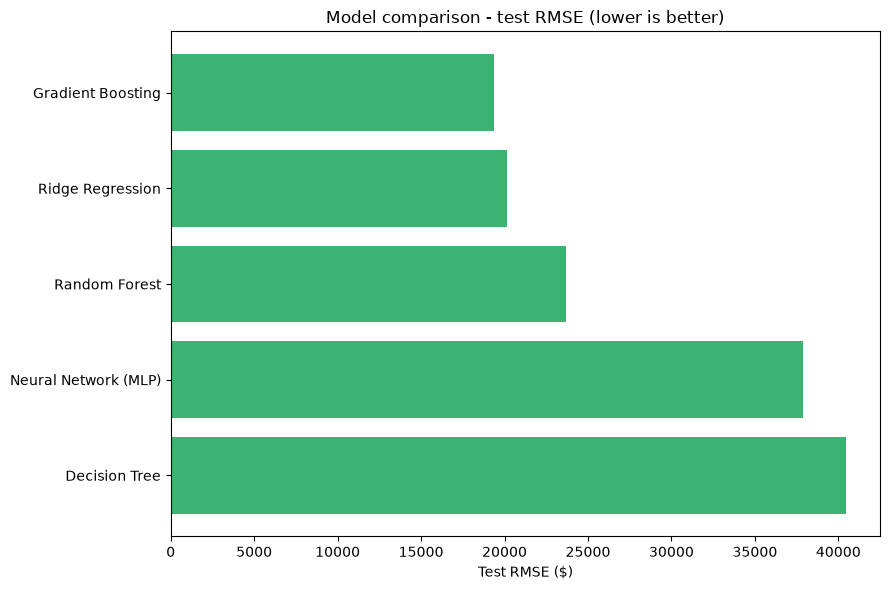

In [77]:
# Linear Regression's RMSE is so much larger than the rest that it would shrink
# every other bar down to nothing, so we leave it out of this particular chart
results_for_chart = results_df[results_df["Model"] != "Linear Regression"]

plt.figure(figsize=(9, 6))
plt.barh(results_for_chart["Model"], results_for_chart["RMSE"], color="mediumseagreen")
plt.gca().invert_yaxis()
plt.xlabel("Test RMSE ($)")
plt.title("Model comparison - test RMSE (lower is better)")
plt.tight_layout()
plt.savefig("../figures/fig_model_comparison.png", dpi=150)
plt.show()

In [78]:
best_model_name = results_df.loc[0, "Model"]
best_pipeline = fitted_pipelines[best_model_name]

print("Best model based on test RMSE:", best_model_name)

Best model based on test RMSE: Gradient Boosting


### 7.1 Which features matter most?

Tree based models can tell us directly which features they relied on most. If the
best model is not a tree-based model, we fall back to the Gradient Boosting model for
this plot instead, since it is one of the strongest and easiest to interpret this
way.

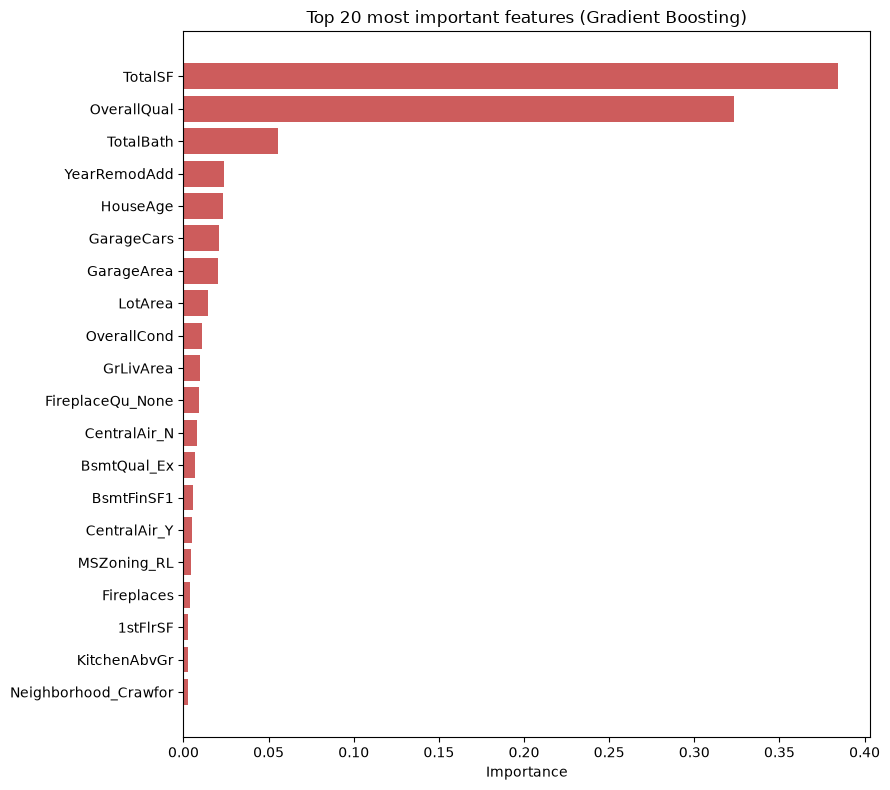

In [79]:
if hasattr(best_pipeline.named_steps["model"], "feature_importances_"):
    importance_model_name = best_model_name
    importance_pipeline = best_pipeline
else:
    importance_model_name = "Gradient Boosting"
    importance_pipeline = fitted_pipelines["Gradient Boosting"]

raw_feature_names = importance_pipeline.named_steps["preprocessing"].get_feature_names_out()
importances = importance_pipeline.named_steps["model"].feature_importances_

# the ColumnTransformer prefixes every name with "numeric__" or "categorical__" -
# that is useful internally, but not very readable in a plot, so we strip it off
clean_feature_names = []
for name in raw_feature_names:
    clean_name = name.replace("numeric__", "").replace("categorical__", "")
    clean_feature_names.append(clean_name)

importance_df = pd.DataFrame()
importance_df["feature"] = clean_feature_names
importance_df["importance"] = importances
importance_df = importance_df.sort_values("importance", ascending=False)

top_20_features = importance_df.head(20)

plt.figure(figsize=(9, 8))
plt.barh(top_20_features["feature"], top_20_features["importance"], color="indianred")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 most important features (" + importance_model_name + ")")
plt.tight_layout()
plt.savefig("../figures/fig_feature_importance.png", dpi=150)
plt.show()

### 7.2 Predicted vs actual price, and residuals

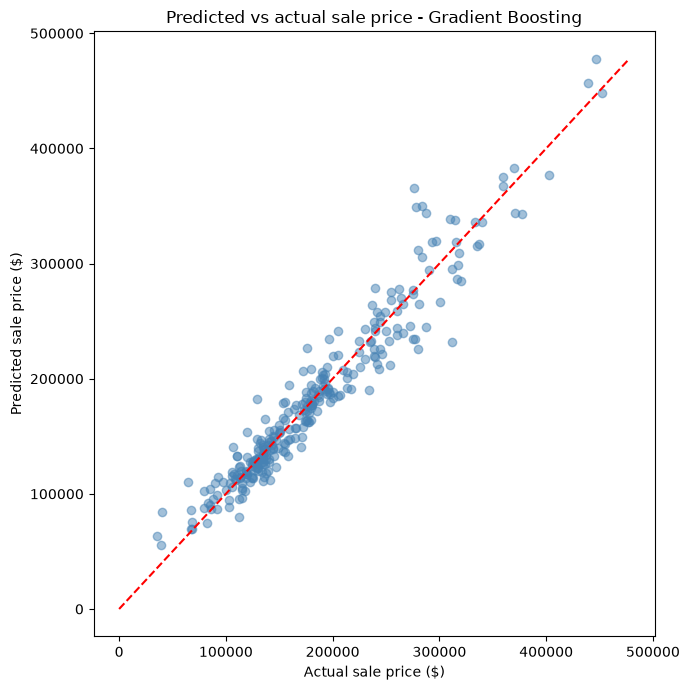

In [80]:
predictions_log = best_pipeline.predict(X_test)
predictions_dollars = np.expm1(predictions_log)
actual_dollars = np.expm1(y_test)

plt.figure(figsize=(7, 7))
plt.scatter(actual_dollars, predictions_dollars, alpha=0.5, color="steelblue")

max_value = max(actual_dollars.max(), predictions_dollars.max())
plt.plot([0, max_value], [0, max_value], color="red", linestyle="--")

plt.xlabel("Actual sale price ($)")
plt.ylabel("Predicted sale price ($)")
plt.title("Predicted vs actual sale price - " + best_model_name)
plt.tight_layout()
plt.savefig("../figures/fig_pred_vs_actual.png", dpi=150)
plt.show()

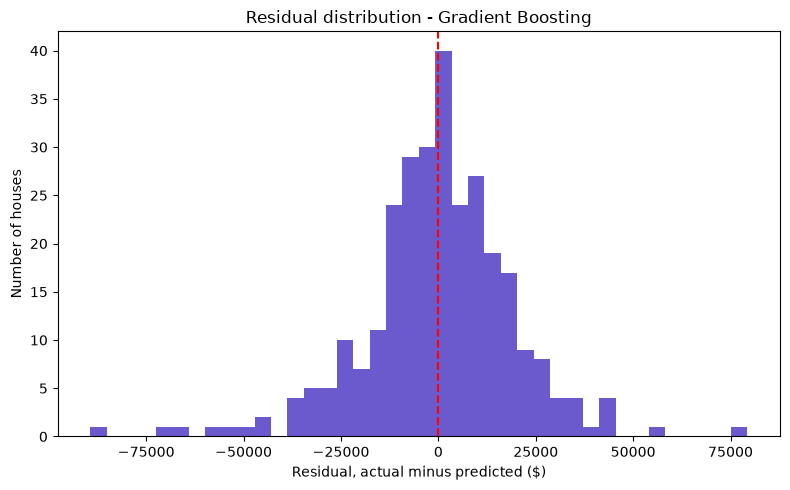

In [81]:
residuals = actual_dollars - predictions_dollars

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40, color="slateblue")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual, actual minus predicted ($)")
plt.ylabel("Number of houses")
plt.title("Residual distribution - " + best_model_name)
plt.tight_layout()
plt.savefig("../figures/fig_residuals.png", dpi=150)
plt.show()

The predicted vs actual plot sits close to the diagonal line for most houses, which
is what we want to see, but the model tends to struggle more with the most expensive
houses there are relatively few of them in the training data, so the model has less
to learn from. The residuals are roughly centered on zero and reasonably symmetric,
with a few larger errors mostly coming from those expensive houses, which matches
what the scatter plot shows.